In [1]:
import pandas as pd

# Load datasets
reddit = pd.read_csv('reddit_final_dataset.csv')
threads = pd.read_csv('threads_cleaned_data.csv')
tiktok = pd.read_csv('tiktok_cleaned_data.csv')
twitter = pd.read_csv('twitter_cleaned_data.csv')

# Add source column
reddit['source'] = 'reddit'
threads['source'] = 'threads'
tiktok['source'] = 'tiktok'
twitter['source'] = 'twitter'

# Combine all
combined_df = pd.concat([reddit, threads, tiktok, twitter], ignore_index=True)

# Keep only needed columns
final_df = combined_df[['Username', 'source', 'lemmatized']]

# Rename for clarity
final_df = final_df.rename(columns={'lemmatized': 'text'})

# Remove null values
final_df = final_df.dropna()

# Optional: remove duplicates (same user same text)
final_df = final_df.drop_duplicates(subset=['Username', 'text'])

# Save final dataset
final_df.to_csv('final_dataset_cleaned.csv', index=False)

In [2]:
import pandas as pd

df = pd.read_csv('final_dataset_cleaned.csv')

# Drop empty
df = df.dropna()

# Check data
print(df.head())

           Username  source                                               text
0           Poltira  reddit  load people sub close gap load people make ldr...
1    AverageJimbo99  reddit  work agree eventually close gap even well set ...
2     User_reddit__  reddit                          work rare case mine didnt
3  SirLunchALot1993  reddit  really depend people super needy cling need lo...
4  OddParamedic4247  reddit                             depends person involve


In [3]:
pip install pandas scikit-learn matplotlib seaborn numpy pillow gensim

Note: you may need to restart the kernel to use updated packages.


In [4]:
#SENTIMENT ANALYSIS

from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = sia.polarity_scores(text)['compound']
    if score > 0.05:
        return 'positive'
    elif score < -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['text'].apply(get_sentiment)

print(df['sentiment'].value_counts())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\syasy\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


sentiment
positive    519
negative    155
neutral     138
Name: count, dtype: int64


In [5]:
#TF IDF 
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['text'])

y = df['sentiment']

In [6]:
#TEST AND SPLIT DATA

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
#MODEL 1 - NAIVE BAYES

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.656441717791411
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        33
     neutral       0.00      0.00      0.00        23
    positive       0.66      1.00      0.79       107

    accuracy                           0.66       163
   macro avg       0.22      0.33      0.26       163
weighted avg       0.43      0.66      0.52       163



C:\Users\syasy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\syasy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\syasy\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [8]:
#MODEL 2- LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
lr_model = LogisticRegression(class_weight='balanced')

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6993865030674846
              precision    recall  f1-score   support

    negative       1.00      0.06      0.11        33
     neutral       1.00      0.22      0.36        23
    positive       0.69      1.00      0.81       107

    accuracy                           0.70       163
   macro avg       0.90      0.43      0.43       163
weighted avg       0.79      0.70      0.61       163



In [9]:
#MODEL 3- SVM

from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train, y_train)


y_pred_svm = svm_model.predict(X_test)

svm_model = LinearSVC(class_weight='balanced')

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.6993865030674846
              precision    recall  f1-score   support

    negative       0.62      0.15      0.24        33
     neutral       0.45      0.39      0.42        23
    positive       0.74      0.93      0.83       107

    accuracy                           0.70       163
   macro avg       0.61      0.49      0.50       163
weighted avg       0.68      0.70      0.65       163



In [10]:
#MODEL 3- SVM - for better recall scores- more balanced

from sklearn.svm import LinearSVC

#svm_model = LinearSVC()
#svm_model.fit(X_train, y_train)
svm_model = LinearSVC(class_weight='balanced', random_state=42)
svm_model.fit(X_train, y_train)

y_pred_svm = svm_model.predict(X_test)

svm_model = LinearSVC(class_weight='balanced')

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))



SVM Accuracy: 0.6748466257668712
              precision    recall  f1-score   support

    negative       0.60      0.18      0.28        33
     neutral       0.37      0.48      0.42        23
    positive       0.76      0.87      0.81       107

    accuracy                           0.67       163
   macro avg       0.57      0.51      0.50       163
weighted avg       0.67      0.67      0.65       163



In [11]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report

# 1. Initialize with balanced weights (crucial for your imbalanced LDR data)
svm_model = LinearSVC(class_weight='balanced', random_state=42)

# 2. Fit the model using your training data
# Ensure X_train and y_train are defined from your previous split
svm_model.fit(X_train, y_train)

# 3. Predict sentiment for the ENTIRE dataset (X) to use in Power BI
df['sentiment'] = svm_model.predict(X)

# 4. Save the final file for your dashboard
df.to_csv('final_dataset_with_sentiment_SVM.csv', index=False)

print("SUCCESS: Model fitted and final_dataset_with_sentiment_SVM.csv saved.")
print(df['sentiment'].value_counts())

SUCCESS: Model fitted and final_dataset_with_sentiment_SVM.csv saved.
sentiment
positive    535
neutral     145
negative    132
Name: count, dtype: int64


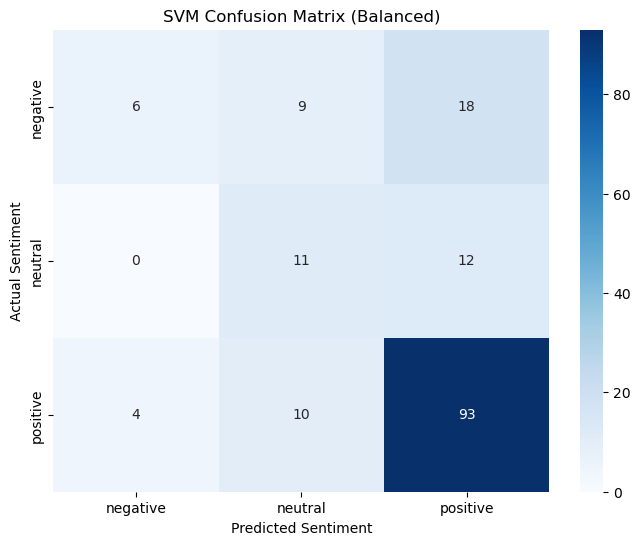

In [12]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline 
# ^ This line tells Jupyter/VS Code to show the plot directly in the notebook

# Then run plotting code
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_svm)
labels = ['negative', 'neutral', 'positive']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.title('SVM Confusion Matrix (Balanced)')
plt.show() 

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest Model
# n_estimators=100 means the model will build 100 individual decision trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7055214723926381
              precision    recall  f1-score   support

    negative       1.00      0.03      0.06        33
     neutral       0.50      0.52      0.51        23
    positive       0.74      0.95      0.83       107

    accuracy                           0.71       163
   macro avg       0.75      0.50      0.47       163
weighted avg       0.76      0.71      0.63       163



In [36]:
#TOPIC MODELLING - LDA

from sklearn.decomposition import LatentDirichletAllocation

lda = LatentDirichletAllocation(n_components=3, random_state=42)
lda.fit(X)

# Show topics
words = vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    print(f"\nTopic {i+1}:")
    print([words[j] for j in topic.argsort()[-10:]])


Topic 1:
['enjoy', 'everyday', 'devotion', 'front', 'someone', 'eye', 'consider', 'louder', 'mean', 'note']

Topic 2:
['person', 'people', 'trust', 'communication', 'ldr', 'love', 'work', 'relationship', 'long', 'distance']

Topic 3:
['get', 'never', 'time', 'together', 'meet', 'ldr', 'work', 'distance', 'long', 'year']


In [15]:
# ============================================================
#  CLUSTERING (K-Means)
#
#  WHY THIS METHOD?
#  - Unsupervised — no labels needed
#  - Groups similar posts to discover natural sub-themes
#  - TF-IDF + L2 normalisation handles variable text lengths
#  - K chosen objectively using Silhouette Score
#
#  EVALUATION:
#    Inertia (Elbow Curve), Silhouette Score per K
#    Top terms per cluster, Cluster × Platform breakdown
# ============================================================
 
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import normalize
 
os.makedirs('outputs', exist_ok=True)
df = pd.read_csv('final_dataset_cleaned.csv').dropna(subset=['text'])
 
# ── TF-IDF Features ──────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X     = tfidf.fit_transform(df['text'])
X_norm = normalize(X)  # L2-normalise for better cosine-based clustering
feature_names = tfidf.get_feature_names_out()
 
# ── Find Best K using Elbow + Silhouette ─────────────────────
K_range   = range(2, 9)
inertias  = []
sil_scores = []
 
print("=" * 50)
print("  FINDING BEST K FOR K-MEANS")
print("=" * 50)
 
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_norm)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_norm, labels, sample_size=500, random_state=42)
    sil_scores.append(sil)
    print(f"  K={k}  Inertia={km.inertia_:.1f}  Silhouette={sil:.4f}")
 
best_k = K_range[np.argmax(sil_scores)]
print(f"\n  Best K = {best_k}  (Silhouette = {max(sil_scores):.4f})")
 
# ── Fit Final Model ──────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = km_final.fit_predict(X_norm)
 
# ── Top Terms per Cluster ────────────────────────────────────
print("\nTop 10 Terms per Cluster:")
cluster_terms = {}
for c in range(best_k):
    top_idx = km_final.cluster_centers_[c].argsort()[::-1][:10]
    terms   = [feature_names[i] for i in top_idx]
    cluster_terms[c] = terms
    print(f"  Cluster {c}: {', '.join(terms)}")
 
# ── Cluster Sizes ─────────────────────────────────────────────
print("\nCluster Sizes:")
for c, cnt in df['cluster'].value_counts().sort_index().items():
    print(f"  Cluster {c}: {cnt} records")
 
# ── Cluster × Platform ────────────────────────────────────────
print("\nCluster × Platform Breakdown:")
print(df.groupby(['cluster', 'source']).size().unstack(fill_value=0).to_string())


# ── Add Cluster Names ─────────────────────────────
cluster_labels = {
    0: "Daily Communication",
    1: "General LDR Talk",
    2: "Skepticism & Negative Outlook",
    3: "Reddit Bot / Noise", 
    4: "Future Planning (Meeting/Moving)", 
    5: "Emotional Core & Trust"
}

df['cluster_name'] = df['cluster'].map(cluster_labels)
 
# Save enriched dataset
df.to_csv('final_dataset_with_clusters.csv', index=False)
print("\nSaved: final_dataset_with_clusters.csv")

  FINDING BEST K FOR K-MEANS
  K=2  Inertia=775.6  Silhouette=0.0078
  K=3  Inertia=764.1  Silhouette=0.0175
  K=4  Inertia=758.7  Silhouette=0.0180
  K=5  Inertia=755.2  Silhouette=0.0168
  K=6  Inertia=752.8  Silhouette=0.0181
  K=7  Inertia=750.8  Silhouette=0.0180
  K=8  Inertia=748.8  Silhouette=0.0165

  Best K = 6  (Silhouette = 0.0181)

Top 10 Terms per Cluster:
  Cluster 0: communication, relationship, time, end, need, thing, like, one, work, make
  Cluster 1: long distance, long, distance, distance relationship, relationship, work, love, would, know, person
  Cluster 2: never, work, ldr, never work, rare, party, anything, ldr never, do never, get
  Cluster 3: participate, karma, please, action, read, moderator, reddit, reddit karma, rule, please contact
  Cluster 4: year, together, meet, month, move, get, work, time, distance, long
  Cluster 5: ldr, love, good, want, say, even, know, trust, partner, feel

Cluster Sizes:
  Cluster 0: 248 records
  Cluster 1: 163 records
  Clus